<a href="https://colab.research.google.com/github/TheraMind-Project-Team/Psychologist-Project-AI/blob/main/Train_Audio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from  google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import r2_score, mean_squared_error

import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.utils import resample
from sklearn.metrics import (r2_score, mean_squared_error,
                              accuracy_score, f1_score,
                              confusion_matrix, classification_report)
import warnings
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
import joblib
warnings.filterwarnings('ignore')
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/clean_audio.csv')

**Regression:**

In [ ]:


X  = df.drop(columns=['participant_id', 'PHQ8_Binary', 'PHQ8_Score'])
y  = df['PHQ8_Score']


sc   = StandardScaler()
X_sc = sc.fit_transform(X)


sel  = SelectKBest(f_regression, k=8)
X_fs = sel.fit_transform(X_sc, y)

model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)

cv       = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores   = cross_val_score(model, X_fs, y, cv=cv, scoring='r2')
rmse_scores = cross_val_score(model, X_fs, y, cv=cv, scoring='neg_root_mean_squared_error')

preds = cross_val_predict(model, X_fs, y, cv=cv)
preds = np.clip(preds, 0, 23)

print("=" * 40)
print("  REGRESSION - PHQ8_Score")
print("=" * 40)
print(f"  R2 Score : {r2_scores.mean():.3f}")
print(f"  RMSE     : {-rmse_scores.mean():.2f}")
print(f"negative   {(preds < 0).sum()}")
print("=" * 40)

  REGRESSION - PHQ8_Score
  R2 Score : 0.068
  RMSE     : 5.65
negative   0


re2

 Final R²  = 0.0621
Final MAE = 4.78


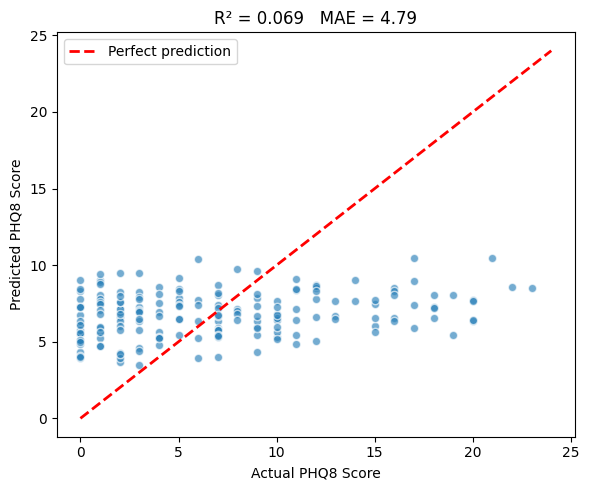

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_regression


X = df.drop(columns=['participant_id', 'PHQ8_Binary', 'PHQ8_Score']).fillna(df.mean())
y = df['PHQ8_Score']

X_eng = X.copy()
X_eng['F2_F1_ratio'] = X['mean_F2'] / (X['mean_F1'] + 1)
X_eng['F3_F2_ratio'] = X['mean_F3'] / (X['mean_F2'] + 1)
X_eng['F4_F3_ratio'] = X['mean_F4'] / (X['mean_F3'] + 1)
X_eng['F2_cv']       = X['std_F2']  / (X['mean_F2'] + 1)
X_eng['C5_range']    = X['max_C5']  - X['min_C5']
X_eng['C1_range']    = X['max_C1']  - X['mean_C1']
X_eng['C1_C2']       = X['mean_C1'] * X['mean_C2']


scaler = RobustScaler()
X_sc = scaler.fit_transform(X_eng)

selector = SelectKBest(score_func=f_regression, k=15)
X_selected = selector.fit_transform(X_sc, y)
selected_features = X_eng.columns[selector.get_support()]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores  = cross_val_score(RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0]),
                              X_selected, y, cv=kf, scoring='r2')
mae_scores = -cross_val_score(RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0]),
                               X_selected, y, cv=kf, scoring='neg_mean_absolute_error')

print(f" Final R²  = {np.mean(r2_scores):.4f}")
print(f"Final MAE = {np.mean(mae_scores):.2f}")


all_actual, all_pred = [], []
for train_idx, test_idx in kf.split(X_selected):
    model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
    model.fit(X_selected[train_idx], y.iloc[train_idx])
    pred = model.predict(X_selected[test_idx])
    all_actual.extend(y.iloc[test_idx].tolist())
    all_pred.extend(pred.tolist())

plt.figure(figsize=(6, 5))
plt.scatter(all_actual, all_pred, alpha=0.65, color='#2980b9', edgecolors='white')
plt.plot([0, 24], [0, 24], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual PHQ8 Score')
plt.ylabel('Predicted PHQ8 Score')
plt.title(f'R² = {r2_score(all_actual, all_pred):.3f}   MAE = {mean_absolute_error(all_actual, all_pred):.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('regression_results.png', dpi=150)
plt.show()

r3

Classfication

In [ ]:
X = df.drop(columns=['participant_id', 'PHQ8_Binary', 'PHQ8_Score'])
y = df['PHQ8_Binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Before balance")
print(f"  Train → Class 0: {(y_train==0).sum()}  |  Class 1: {(y_train==1).sum()}")
print(f"  Test  → Class 0: {(y_test==0).sum()}   |  Class 1: {(y_test==1).sum()}")


Before balance
  Train → Class 0: 104  |  Class 1: 45
  Test  → Class 0: 27   |  Class 1: 11


In [ ]:
train_df  = pd.concat([X_train, y_train], axis=1)
maj       = train_df[train_df.PHQ8_Binary == 0]
mn        = train_df[train_df.PHQ8_Binary == 1]
mn_up     = resample(mn, replace=True, n_samples=len(maj), random_state=42)
train_bal = pd.concat([maj, mn_up]).sample(frac=1, random_state=42)

X_tr = train_bal.drop(columns='PHQ8_Binary')
y_tr = train_bal['PHQ8_Binary']

sc        = StandardScaler()
X_tr_sc   = sc.fit_transform(X_tr)
X_te_sc   = sc.transform(X_test)

sel_clf = SelectKBest(f_classif, k=25)
X_tr_fs   = sel_clf.fit_transform(X_tr_sc, y_tr)
X_te_fs   = sel_clf.transform(X_te_sc)

In [ ]:

model_clf = ExtraTreesClassifier(
    n_estimators    = 500,
    max_depth       = 4,
    min_samples_leaf= 1,
    class_weight    = 'balanced',
    random_state    = 42,

)
model_clf.fit(X_tr_fs, y_tr)
preds = model_clf.predict(X_te_fs)

print("\n" + "="*45)
print("   result Test Set")
print("="*45)
print(f"  Accuracy : {accuracy_score(y_test, preds)*100:.1f}%")
print(f"  F1 Score : {f1_score(y_test, preds, zero_division=0):.3f}")
print()
print(classification_report(y_test, preds, target_names=['Not Depress', ' Depress']))
joblib.dump(model_clf,"model_clf_audio")
joblib.dump(sel_clf,"selector_25")


   result Test Set
  Accuracy : 73.7%
  F1 Score : 0.444

              precision    recall  f1-score   support

 Not Depress       0.77      0.89      0.83        27
     Depress       0.57      0.36      0.44        11

    accuracy                           0.74        38
   macro avg       0.67      0.63      0.64        38
weighted avg       0.72      0.74      0.72        38



['selector_25']

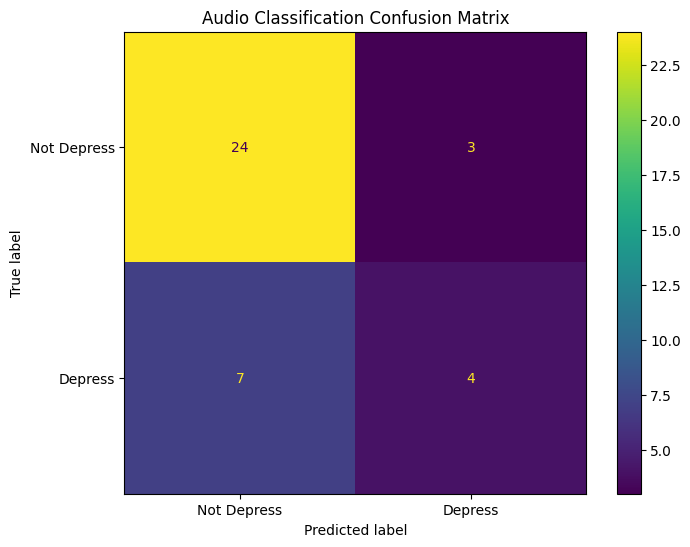

['selector_25']

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib


cm = confusion_matrix(y_test, preds)
labels = ['Not Depress', 'Depress']


fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap='viridis', ax=ax, values_format='d')

plt.title('Audio Classification Confusion Matrix')
plt.show()

joblib.dump(model_clf, "model_clf_audio")
joblib.dump(sel_clf, "selector_25")

In [ ]:

models = {
    "ExtraTrees":         ExtraTreesClassifier(n_estimators=500, max_depth=4,
                                               class_weight='balanced', random_state=42),
    "RandomForest":       RandomForestClassifier(n_estimators=500, max_depth=4,
                                                 class_weight='balanced', random_state=42),
    "GradientBoosting":   GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                                      learning_rate=0.05, random_state=42),
    "AdaBoost":           AdaBoostClassifier(n_estimators=200, learning_rate=0.1,
                                              random_state=42),
    "SVM (RBF)":          SVC(kernel='rbf', C=1.0, class_weight='balanced',
                               probability=True, random_state=42),
    "SVM (Linear)":       SVC(kernel='linear', C=0.5, class_weight='balanced',
                               probability=True, random_state=42),
    "LogisticRegression": LogisticRegression(C=0.5, class_weight='balanced',
                                              max_iter=1000, random_state=42),
    "KNN":                KNeighborsClassifier(n_neighbors=7, weights='distance'),
}




In [ ]:
print("=" * 70)
print(f"{'Model':<22} {'Accuracy':>9} {'F1':>9} {'AUC-ROC':>9} {'Sensitivity':>12} {'Specificity':>12}")
print("=" * 70)

results = []

for name, model in models.items():
    model.fit(X_tr_fs, y_tr)
    preds = model.predict(X_te_fs)
    probs = model.predict_proba(X_te_fs)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test, preds)
    f1   = f1_score(y_test, preds, zero_division=0)
    auc  = roc_auc_score(y_test, probs) if probs is not None else float('nan')

    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall for class 1
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Recall for class 0

    results.append({
        'Model': name, 'Accuracy': acc, 'F1': f1,
        'AUC-ROC': auc, 'Sensitivity': sensitivity, 'Specificity': specificity
    })

    print(f"{name:<22} {acc*100:>8.1f}% {f1:>9.3f} {auc:>9.3f} {sensitivity*100:>11.1f}% {specificity*100:>11.1f}%")


print("\n" + "=" * 70)
best = max(results, key=lambda r: r['F1'])
print(f"  Best Model F1: {best['Model']}  (F1 = {best['F1']:.3f})")
print("=" * 70)

best_model = models[best['Model']]
preds_best = best_model.predict(X_te_fs)
print(f"\n📋 Classification Report - {best['Model']}:")
print(classification_report(y_test, preds_best, target_names=['Not Depressed', 'Depress']))


print("\n" + "=" * 70)
print("   Cross-Validation (5-Fold)  All Data ")
print("=" * 70)
print(f"{'Model':<22} {'CV F1 Mean':>12} {'CV F1 Std':>12}")
print("-" * 46)

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(f_classif, k=25)),
        ('clf', model)
    ])
    cv_scores = cross_val_score(pipe, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                 scoring='f1', n_jobs=-1)
    print(f"{name:<22} {cv_scores.mean():>11.3f}  ±{cv_scores.std():>9.3f}")

Model                   Accuracy        F1   AUC-ROC  Sensitivity  Specificity
ExtraTrees                 73.7%     0.444     0.532        36.4%        88.9%
RandomForest               63.2%     0.300     0.505        27.3%        77.8%
GradientBoosting           57.9%     0.200     0.471        18.2%        74.1%
AdaBoost                   47.4%     0.286     0.471        36.4%        51.9%
SVM (RBF)                  68.4%     0.333     0.532        27.3%        85.2%
SVM (Linear)               50.0%     0.240     0.404        27.3%        59.3%
LogisticRegression         57.9%     0.333     0.475        36.4%        66.7%
KNN                        60.5%     0.286     0.556        27.3%        74.1%

  Best Model F1: ExtraTrees  (F1 = 0.444)

📋 Classification Report - ExtraTrees:
               precision    recall  f1-score   support

Not Depressed       0.77      0.89      0.83        27
      Depress       0.57      0.36      0.44        11

     accuracy                           



Hypired output classfication to input Regression
```



In [ ]:
warnings.filterwarnings('ignore')
X = df.drop(columns=['participant_id', 'PHQ8_Binary', 'PHQ8_Score'])
y = df['PHQ8_Score']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


train_df = pd.concat([X_train, y_train], axis=1)
low = train_df[train_df.PHQ8_Score <= 9]
high = train_df[train_df.PHQ8_Score >= 10]
high_up = resample(high, replace=True, n_samples=len(low), random_state=42)
train_bal = pd.concat([low, high_up]).sample(frac=1, random_state=42)

X_tr = train_bal.drop(columns='PHQ8_Score')
y_tr = train_bal['PHQ8_Score']

sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_test)

In [ ]:
clf_model = joblib.load('model_clf_audio')
sel_25 = joblib.load('selector_25')


X_tr_25 = sel_25.transform(X_tr_sc)
X_te_25 = sel_25.transform(X_te_sc)
train_preds_bin = clf_model.predict(X_tr_25).reshape(-1, 1)
test_preds_bin = clf_model.predict(X_te_25).reshape(-1, 1)

# 2. استخراج الاحتمالية (0.0 لـ 1.0)
train_probs = clf_model.predict_proba(X_tr_25)[:, 1].reshape(-1, 1)
test_probs = clf_model.predict_proba(X_te_25)[:, 1].reshape(-1, 1)

In [ ]:
from sklearn.linear_model import Ridge

sel_4 = SelectKBest(f_regression, k=4)
X_tr_4 = sel_4.fit_transform(X_tr_sc, y_tr)
X_te_4 = sel_4.transform(X_te_sc)

X_tr_hybrid_raw = np.hstack((X_tr_4, train_preds_bin, train_probs))
X_te_hybrid_raw = np.hstack((X_te_4, test_preds_bin, test_probs))

#. Scaling the hybrid features
sc_hybrid = StandardScaler()
X_tr_hybrid = sc_hybrid.fit_transform(X_tr_hybrid_raw)
X_te_hybrid = sc_hybrid.transform(X_te_hybrid_raw)
model_reg = Ridge(alpha=10.0)
model_reg.fit(X_tr_hybrid, y_tr)

Ridge(alpha=10.0)

In [ ]:

# . التقييم
preds = np.clip(model_reg.predict(X_te_hybrid), 0, 23)
r2 = r2_score(y_test, preds)
rmse = mean_squared_error(y_test, preds) ** 0.5
import joblib

joblib.dump(model_reg, 'audio_reg_hybrid.pkl')


joblib.dump(sel_4, 'audio_selector_4.pkl')

joblib.dump(sc, 'audio_scaler.pkl')

joblib.dump(sc_hybrid, 'audio_hybrid.pkl')
print("\n" + "=" * 40)
print(" HYBRID REGRESSION RESULTS")
print("=" * 40)
print(f" R2 Score (Accuracy): {r2:.3f}")
print(f"RMSE (Error)       : {rmse:.2f}")



 HYBRID REGRESSION RESULTS
 R2 Score (Accuracy): 0.370
RMSE (Error)       : 4.47


In [ ]:
warnings.filterwarnings('ignore')

df = df.fillna(df.mean(numeric_only=True))

In [ ]:

print("After Balanced")
print(f"  Low (PHQ8≤9)  : {(y_tr <= 9).sum()}")
print(f"  High (PHQ8≥10): {(y_tr >= 10).sum()}")
print(f"  Test set      : {len(y_test)} samples\n")

After Balanced
  Low (PHQ8≤9)  : 108
  High (PHQ8≥10): 108
  Test set      : 38 samples



In [ ]:

#  ═══════════════  REGRESSION MODELS  ════════════════════════════════════


from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor)
from sklearn.svm import SVR

DEPRESSION_THRESHOLD = 9

models = {
    "Ridge":          Ridge(alpha=10.0),
    "RandomForest":   RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42),
    "ExtraTrees":     ExtraTreesRegressor(n_estimators=300, max_depth=5, random_state=42),
    "GradBoosting":   GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                  learning_rate=0.05, random_state=42),
    "SVR (RBF)":      SVR(kernel='rbf', C=10, epsilon=0.5),
    "SVR (Linear)":   SVR(kernel='linear', C=1.0, epsilon=0.5),
}



In [ ]:
y_bin_test = (y_test >= DEPRESSION_THRESHOLD).astype(int)

all_results = []
all_preds   = {}

print("=" * 95)
print(f"   compering  Regression with Threshold = {DEPRESSION_THRESHOLD} ")
print("=" * 95)
print(f"{'Model':<16} {'R²':>7} {'RMSE':>7} {'MAE':>7}  │  {'Acc':>7} {'F1':>7} {'Sensitivity':>12} {'Specificity':>12}")
print("-" * 95)

for name, model in models.items():
    model.fit(X_tr_hybrid, y_tr)
    preds     = np.clip(model.predict(X_te_hybrid), 0, 23)
    all_preds[name] = preds

    r2   = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae  = np.mean(np.abs(y_test - preds))

    preds_bin = (preds >= DEPRESSION_THRESHOLD).astype(int)
    acc  = accuracy_score(y_bin_test, preds_bin)
    f1   = f1_score(y_bin_test, preds_bin, zero_division=0)
    cm   = confusion_matrix(y_bin_test, preds_bin)
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0   # Recall for depression
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0   # Recall for no-depression

    all_results.append({
        'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae,
        'Acc': acc, 'F1': f1, 'Sensitivity': sens, 'Specificity': spec,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    })

    print(f"{name:<16} {r2:>7.3f} {rmse:>7.2f} {mae:>7.2f}  │  {acc*100:>6.1f}% {f1:>7.3f} {sens*100:>11.1f}% {spec*100:>11.1f}%")

print("=" * 95)
best_r2  = max(all_results, key=lambda x: x['R2'])
best_f1  = max(all_results, key=lambda x: x['F1'])
print(f"\n BEST R²  : {best_r2['Model']:<16} R²={best_r2['R2']:.3f}  RMSE={best_r2['RMSE']:.2f}")
print(f" BEST F1  : {best_f1['Model']:<16} F1={best_f1['F1']:.3f}  Acc={best_f1['Acc']*100:.1f}%\n")




   compering  Regression with Threshold = 9 
Model                 R²    RMSE     MAE  │      Acc      F1  Sensitivity  Specificity
-----------------------------------------------------------------------------------------------
Ridge              0.370    4.47    3.34  │    81.6%   0.800        66.7%       100.0%
RandomForest       0.224    4.96    3.94  │    71.1%   0.645        47.6%       100.0%
ExtraTrees         0.224    4.96    3.95  │    68.4%   0.600        42.9%       100.0%
GradBoosting       0.326    4.62    3.50  │    73.7%   0.688        52.4%       100.0%
SVR (RBF)          0.195    5.05    3.92  │    71.1%   0.667        52.4%        94.1%
SVR (Linear)       0.343    4.56    3.29  │    78.9%   0.765        61.9%       100.0%

 BEST R²  : Ridge            R²=0.370  RMSE=4.47
 BEST F1  : Ridge            F1=0.800  Acc=81.6%



In [ ]:

#  ═══════════  CONFUSION MATRIX every model and report classfication ═══════════════════════════════


print("\n" + "=" * 70)
print("   Confusion Matrix + Classification Report لكل نموذج")
print(f"     (Threshold = {DEPRESSION_THRESHOLD} | PHQ8 ≥ {DEPRESSION_THRESHOLD} → اكتئاب)")
print("=" * 70)

for r in all_results:
    name = r['Model']
    preds_bin = (all_preds[name] >= DEPRESSION_THRESHOLD).astype(int)

    print(f"\n{'─'*50}")
    print(f"   {name}")
    print(f"{'─'*50}")
    print(f"  R² = {r['R2']:.3f}  |  RMSE = {r['RMSE']:.2f}  |  MAE = {r['MAE']:.2f}")
    print(f"  Accuracy = {r['Acc']*100:.1f}%  |  F1 = {r['F1']:.3f}")
    print(f"  Sensitivity (Recall Depress) = {r['Sensitivity']*100:.1f}%")
    print(f"  Specificity (Recall Not Depress) = {r['Specificity']*100:.1f}%")

    print(f"\n  Confusion Matrix (Threshold={DEPRESSION_THRESHOLD}):")
    print(f"  {'':>15} Pred: Not Depress Pred:Depress")
    print(f"  Actual: Not Depress    {r['TN']:>5}          {r['FP']:>5}")
    print(f"  Actual: Depress        {r['FN']:>5}          {r['TP']:>5}")

    print(f"\n  Classification Report:")
    print(classification_report(y_bin_test, preds_bin,
                                 target_names=['Not Depress', 'Depress'],
                                 zero_division=0))

print("\n" + "=" * 70)
print("   Threshold Analysis - Ridge (Best R²)")
print("  thresholds ")
print("=" * 70)

ridge_preds = all_preds['Ridge']
print(f"\n{'Threshold':>10} {'Depression Label':>18} {'Acc':>8} {'F1':>8} {'Sens':>8} {'Spec':>8}")
print("-" * 65)

for t in [5, 8, 10, 12, 15]:
    y_bin_t   = (y_test >= t).astype(int)
    p_bin_t   = (ridge_preds >= t).astype(int)
    if y_bin_t.sum() == 0 or y_bin_t.sum() == len(y_bin_t):
        continue
    acc_t  = accuracy_score(y_bin_t, p_bin_t)
    f1_t   = f1_score(y_bin_t, p_bin_t, zero_division=0)
    cm_t   = confusion_matrix(y_bin_t, p_bin_t)
    tn_,fp_,fn_,tp_ = cm_t.ravel()
    sens_t = tp_/(tp_+fn_) if (tp_+fn_)>0 else 0
    spec_t = tn_/(tn_+fp_) if (tn_+fp_)>0 else 0
    label  = "Mild+" if t==5 else "Moderate+" if t==10 else "Mod-Severe+" if t==15 else f"PHQ8≥{t}"
    print(f"  PHQ8≥{t:>2}  {label:>18}  {acc_t*100:>7.1f}%  {f1_t:>7.3f}  {sens_t*100:>7.1f}%  {spec_t*100:>7.1f}%")

print("\n" + "=" * 70)

best_model_name = best_r2['Model']
best_model_obj  = models[best_model_name]

joblib.dump(best_model_obj, 'audio_reg_hybrid.pkl')
joblib.dump(sel_4,          'audio_selector_4.pkl')
joblib.dump(sc,             'audio_scaler.pkl')
joblib.dump(sc_hybrid,      'audio_scaler_hybrid.pkl')

print(f" Best Model ({best_model_name}) saved as 'audio_reg_hybrid.pkl'")
print(f"  audio_selector_4.pkl")
print(f"   audio_scaler.pkl")
print(f"  audio_scaler_hybrid.pkl")

print(f"  Depression Threshold = {DEPRESSION_THRESHOLD} (PHQ8 Moderate+)")


   Confusion Matrix + Classification Report لكل نموذج
     (Threshold = 9 | PHQ8 ≥ 9 → اكتئاب)

──────────────────────────────────────────────────
   Ridge
──────────────────────────────────────────────────
  R² = 0.370  |  RMSE = 4.47  |  MAE = 3.34
  Accuracy = 81.6%  |  F1 = 0.800
  Sensitivity (Recall Depress) = 66.7%
  Specificity (Recall Not Depress) = 100.0%

  Confusion Matrix (Threshold=9):
                  Pred: Not Depress Pred:Depress
  Actual: Not Depress       17              0
  Actual: Depress            7             14

  Classification Report:
              precision    recall  f1-score   support

 Not Depress       0.71      1.00      0.83        17
     Depress       1.00      0.67      0.80        21

    accuracy                           0.82        38
   macro avg       0.85      0.83      0.81        38
weighted avg       0.87      0.82      0.81        38


──────────────────────────────────────────────────
   RandomForest
──────────────────────────────────